In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt


In [2]:
def pwr_system_equations(t, y, Lambda, beta, lam, rho_inserted):
    # --- Unpack State Variables ---
    n = y[0]  # Current neutron power level
    C = y[1]  # Current delayed neutron precursor count

    # --- Equation 1: Rate of change for Neutron Power ---
    # Calculates how fast the power climbs or falls
    dn_dt = ((rho_inserted - beta) / Lambda) * n + lam * C

    # --- Equation 2: Rate of change for Precursors ---
    # Calculates how fast radioactive fragments build up or decay
    dC_dt = (beta / Lambda) * n - lam * C

    # Return both rates of change back to the solver
    return [dn_dt, dC_dt]

In [3]:
import numpy as np
from scipy.integrate import solve_ivp

# --- Nuclear Constants ---
Lambda = 1e-4  # Prompt neutron lifetime
beta = 0.0065  # Delayed neutron fraction
lam = 0.08     # Precursor decay constant

# --- Initial Conditions ---
n0 = 1.0
C0 = (beta / (Lambda * lam)) * n0
initial_state = [n0, C0]

# --- Parameters ---
time_span = (0.0, 15.0)
t_eval = np.linspace(0, 15, 1000)
rho_inserted = -0.05                # Positive reactivity climb

# --- Run Solver ---
solution = solve_ivp(
    pwr_system_equations,
    time_span,
    initial_state,
    args=(Lambda, beta, lam, rho_inserted),
    t_eval=t_eval
)

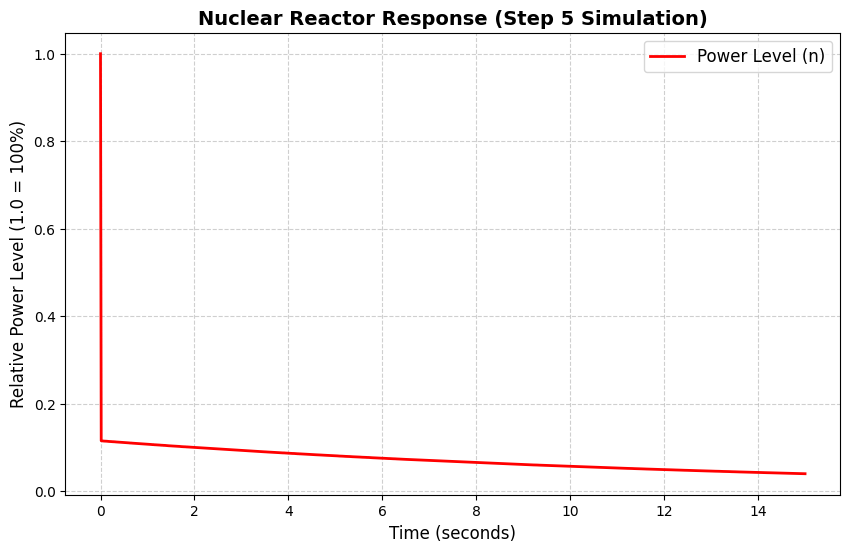

In [4]:
import matplotlib.pyplot as plt

# --- Extract Only the Power Data Row ---
# solution.y[0] isolates the first row (relative power level)
power_level = solution.y[0]

# --- Create the Plot ---
plt.figure(figsize=(10, 6))
plt.plot(solution.t, power_level, label='Power Level (n)', color='red', linewidth=2)

# --- Format the Layout ---
plt.title('Nuclear Reactor Response (Step 5 Simulation)', fontsize=14, fontweight='bold')
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Relative Power Level (1.0 = 100%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

# --- Display Graph ---
plt.show()

In [5]:
!pip install -q streamlit scipy matplotlib numpy
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏
changed 22 packages in 2s
⠏
⠏3 packages are looking for funding
⠏  run `npm fund` for details
⠏

In [6]:
%%writefile app.py
import streamlit as st
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# --- App Title & Layout ---
st.set_page_config(page_title="Nuclear Reactor Simulator", layout="wide")
st.title("☢️ Interactive Nuclear Reactor Kinetics Simulator")
st.write("Modify the control rods or trigger an emergency SCRAM to see how the core responds in real-time.")

# --- Sidebar Control Panel ---
st.sidebar.header("🕹️ Control Room Console")
scram_triggered = st.sidebar.button("💥 TRIGGER EMERGENCY SCRAM", type="primary")

if scram_triggered:
    rho_inserted = -0.05
    st.sidebar.error("🚨 SCRAM ACTIVATED: Control rods fully dropped!")
else:
    rho_inserted = st.sidebar.slider(
        "Control Rod Position (Reactivity)",
        min_value=-0.0050, max_value=0.0050, value=0.0015, step=0.0005, format="%.4f"
    )

beta = st.sidebar.slider("Delayed Neutron Fraction (beta)", 0.0040, 0.0080, 0.0065, 0.0005)
Lambda = 1e-4
lam = 0.08

# --- Physics Simulation Engine ---
def reactor_equations(t, y, Lambda, beta, lam, rho):
    n, C = y[0], y[1]
    dn_dt = ((rho - beta) / Lambda) * n + lam * C
    dC_dt = (beta / Lambda) * n - lam * C
    return [dn_dt, dC_dt]

t_eval = np.linspace(0, 15, 1000)
initial_state = [1.0, (beta / (Lambda * lam)) * 1.0]

solution = solve_ivp(
    reactor_equations, (0.0, 15.0), initial_state,
    args=(Lambda, beta, lam, rho_inserted), t_eval=t_eval
)
power_level = solution.y[0]

# --- Render Visual Graph ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(solution.t, power_level, color="red" if rho_inserted > 0 else "green", linewidth=2.5)
ax.set_title("Core Thermal Power Response Timeline", fontsize=14, fontweight="bold")
ax.set_xlabel("Time (Seconds)", fontsize=11)
ax.set_ylabel("Relative Power Level (1.0 = 100%)", fontsize=11)
ax.grid(True, linestyle="--", alpha=0.5)
st.pyplot(fig)

# --- Real-Time Data Readout ---
col1, col2 = st.columns(2)
with col1:
    st.metric(label="Current Reactivity Status", value=f"{rho_inserted:.4f}")
with col2:
    st.metric(label="Peak Power Level Reached", value=f"{max(power_level):.2f}x")

Overwriting app.py


In [7]:
!curl ifconfig.me

34.56.141.178

In [9]:
!pip install pyngrok -q

In [10]:
from pyngrok import ngrok

# Links your Colab notebook to your ngrok account
ngrok.set_auth_token("3FqQqgeDuMf08NavBQFUVXu0v3P_3FNRRrZxZ39EiepWnUkSR")

In [13]:
# Print out the exact contents of your app file to check for typos
print("--- Content of app.py ---")
with open("app.py", "r") as f:
    print(f.read())

print("\n--- Diagnostic Server Run ---")
# Run streamlit directly in text-only mode to see why it is crashing
!streamlit run app.py --server.port 8501 --logger.level=debug & sleep 4

--- Content of app.py ---
import streamlit as st
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# --- App Title & Layout ---
st.set_page_config(page_title="Nuclear Reactor Simulator", layout="wide")
st.title("☢️ Interactive Nuclear Reactor Kinetics Simulator")
st.write("Modify the control rods or trigger an emergency SCRAM to see how the core responds in real-time.")

# --- Sidebar Control Panel ---
st.sidebar.header("🕹️ Control Room Console")
scram_triggered = st.sidebar.button("💥 TRIGGER EMERGENCY SCRAM", type="primary")

if scram_triggered:
    rho_inserted = -0.05
    st.sidebar.error("🚨 SCRAM ACTIVATED: Control rods fully dropped!")
else:
    rho_inserted = st.sidebar.slider(
        "Control Rod Position (Reactivity)", 
        min_value=-0.0050, max_value=0.0050, value=0.0015, step=0.0005, format="%.4f"
    )

beta = st.sidebar.slider("Delayed Neutron Fraction (beta)", 0.0040, 0.0080, 0.0065, 0.0005)
Lambda = 1e-4  
lam = 0.08     

# -

In [16]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# --- 1. Core Physics Simulation Engine ---
def reactor_equations(t, y, Lambda, beta, lam, rho):
    n, C = y[0], y[1]
    dn_dt = ((rho - beta) / Lambda) * n + lam * C
    dC_dt = (beta / Lambda) * n - lam * C
    return [dn_dt, dC_dt]

# --- 2. Interactive Logic Controller ---
def run_live_simulation(change=None):
    with output_box:
        clear_output(wait=True) # Wipes the old plot cleanly

        # Check if SCRAM mode is active
        is_scram = scram_toggle.value
        if is_scram:
            rho_inserted = -0.05
            print("🚨 EMERGENCY SCRAM ACTIVATED: Control Rods Fully Inserted!")
        else:
            rho_inserted = rod_slider.value
            print(f"🕹️ Control Room Status: Rod Reactivity set to {rho_inserted:.4f}")

        beta = beta_slider.value
        Lambda, lam = 1e-4, 0.08

        # Run Physics Calculus Solver
        t_eval = np.linspace(0, 15, 1000)
        initial_state = [1.0, (beta / (Lambda * lam)) * 1.0]

        solution = solve_ivp(
            reactor_equations, (0.0, 15.0), initial_state,
            args=(Lambda, beta, lam, rho_inserted), t_eval=t_eval
        )
        power_level = solution.y[0]

        # Build the Visual Chart
        plt.figure(figsize=(10, 4.5))
        plot_color = "green" if rho_inserted <= 0 else "red"
        plt.plot(solution.t, power_level, color=plot_color, linewidth=2.5, label="Power Level (n)")

        plt.title("☢️ Live Nuclear Reactor Core Response Timeline", fontsize=13, fontweight='bold')
        plt.xlabel("Time (Seconds)", fontsize=10)
        plt.ylabel("Relative Power Level (1.0 = 100%)", fontsize=10)
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.ylim(0, max(2.1, max(power_level) * 1.1))
        plt.legend(loc="upper left")
        plt.show()

        print(f"📈 Peak Power Reached: {max(power_level):.2f}x of baseline operating capacity.")

# --- 3. Construct Visual Interface Widgets ---
rod_slider = widgets.FloatSlider(
    value=0.0015, min=-0.0050, max=0.0050, step=0.0005,
    description='Control Rods:', readout_format='.4f', layout=widgets.Layout(width='450px')
)

beta_slider = widgets.FloatSlider(
    value=0.0065, min=0.0040, max=0.0080, step=0.0005,
    description='Beta Fraction:', readout_format='.4f', layout=widgets.Layout(width='450px')
)

scram_toggle = widgets.ToggleButton(
    value=False, description='💥 TRIGGER EMERGENCY SCRAM',
    button_style='danger', layout=widgets.Layout(width='250px', height='35px')
)

# Output container to isolate graph flashing
output_box = widgets.Output()

# --- 4. Wire Up Live Interactions ---
rod_slider.observe(run_live_simulation, names='value')
beta_slider.observe(run_live_simulation, names='value')
scram_toggle.observe(run_live_simulation, names='value')

# --- 5. Force Simultaneous Layout Render ---
control_panel = widgets.VBox([
    widgets.HTML("<h3>⚙️ NUCLEAR REACTOR CONTROL CONSOLE</h3>"),
    rod_slider,
    beta_slider,
    scram_toggle
])

# Renders controls and graphic window together cleanly
display(widgets.VBox([control_panel, output_box]))
run_live_simulation()